In [17]:
import os
print(os.getcwd())

c:\Users\user\Desktop\hackathon


In [18]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Отключаем защитный лимит Pillow на размер изображений
Image.MAX_IMAGE_PIXELS = None

def get_img_resolution(img_path):
    with Image.open(img_path) as img:
        return img.size # (width, height)

# Включаем интерактивное отображение графиков
%matplotlib inline

# Настройки путей (подставь свой путь к датасету)
import os
from pathlib import Path

import os
from pathlib import Path

# Указываем корневую папку с датасетом, которую показал ls -l
DATA_DIR = Path("Задача 3. Скажи мне, кто твой шлиф")

# Теперь пути будут строиться правильно: "Задача 3. Скажи мне.../Панорамы" и т.д.
PANORAMAS_DIR = DATA_DIR / "Панорамы"
ORES_PART1 = DATA_DIR / "Фото руд по сортам. ч1"
ORES_PART2 = DATA_DIR / "Фото руд по сортам. ч2"

# Проверяем заново
for path in [PANORAMAS_DIR, ORES_PART1, ORES_PART2]:
    print(f"Папка '{path.name}': {'НАЙДЕНА' if path.exists() else '❌ НЕ НАЙДЕНА'}")
# Быстрая проверка на то, видит ли Python папки
# Константы для визуализации (согласно ТЗ)
COLOR_MAP = {
    'normal': (0, 255, 0),  # Зеленый - обычные срастания
    'thin': (255, 0, 0),    # Красный - тонкие срастания
    'talc': (0, 0, 255)     # Синий - тальк
}

Папка 'Панорамы': НАЙДЕНА
Папка 'Фото руд по сортам. ч1': НАЙДЕНА
Папка 'Фото руд по сортам. ч2': НАЙДЕНА


In [19]:
def collect_dataset_info(base_dir):
    records = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')
    
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(valid_extensions):
                file_path = Path(root) / file
                size_mb = os.path.getsize(file_path) / (1024 * 1024)
                
                # Определяем класс по имени папки
                folder_name = file_path.parent.name.lower()
                
                records.append({
                    'path': str(file_path),
                    'filename': file,
                    'folder': file_path.parent.name,
                    'size_mb': size_mb,
                    'part': base_dir.name
                })
    return pd.DataFrame(records)

# Собираем данные по всем папкам
df_part1 = collect_dataset_info(ORES_PART1)
df_part2 = collect_dataset_info(ORES_PART2)
df_panoramas = collect_dataset_info(PANORAMAS_DIR)

df_all = pd.concat([df_part1, df_part2, df_panoramas], ignore_index=True)
print(f"Всего изображений найдено: {len(df_all)}")
df_all.sample(5)

Всего изображений найдено: 1236


,path,filename,folder,size_mb,part
493,"Задача 3. Скажи мне, кто твой шлиф\Фото руд по...",63.jpg,рядовые,0.462590,Фото руд по сортам. ч2
749,"Задача 3. Скажи мне, кто твой шлиф\Фото руд по...",DSCN4436.JPG,рядовые,0.800297,Фото руд по сортам. ч2
550,"Задача 3. Скажи мне, кто твой шлиф\Фото руд по...",DSCN0638.JPG,рядовые,0.771081,Фото руд по сортам. ч2
18,"Задача 3. Скажи мне, кто твой шлиф\Фото руд по...",DSCN4695.JPG,Оталькованные руды,0.760919,Фото руд по сортам. ч1
1227,"Задача 3. Скажи мне, кто твой шлиф\Панорамы\15...",15.jpg,Панорамы,53.801095,Панорамы


In [20]:
def map_class(folder_name):
    folder = folder_name.lower()
    if 'оталькован' in folder:
        return 'оталькованная'
    elif 'рядов' in folder:
        return 'рядовая'
    elif 'труднообогатим' in folder or 'тонк' in folder:
        return 'труднообогатимая'
    elif 'панорам' in folder:
        return 'панорама (тест/валидация)'
    return 'неизвестно'

df_all['ore_class'] = df_all['folder'].apply(map_class)
print("Распределение изображений по классам руды:")
print(df_all['ore_class'].value_counts())

Распределение изображений по классам руды:
ore_class
рядовая                      565
труднообогатимая             486
оталькованная                171
панорама (тест/валидация)     14
Name: count, dtype: int64


In [21]:
def get_img_resolution(img_path):
    with Image.open(img_path) as img:
        return img.size # (width, height)

# Для скорости проверим случайную выборку или топ больших файлов
print("Извлекаем разрешения для панорам...")
panoramas = df_all[df_all['ore_class'] == 'панорама (тест/валидация)'].copy()
panoramas['resolution'] = panoramas['path'].apply(get_img_resolution)

print("\nПримеры разрешений тяжелых панорам:")
print(panoramas[['filename', 'size_mb', 'resolution']].head())

Извлекаем разрешения для панорам...

Примеры разрешений тяжелых панорам:
     filename     size_mb      resolution
1222   10.jpg   52.169752  (14999, 10391)
1223   11.jpg   46.695422   (13416, 9642)
1224   12.jpg   53.774762  (14113, 10339)
1225   13.jpg   46.273800   (13330, 9489)
1226   14.jpg  109.626694  (20642, 14585)


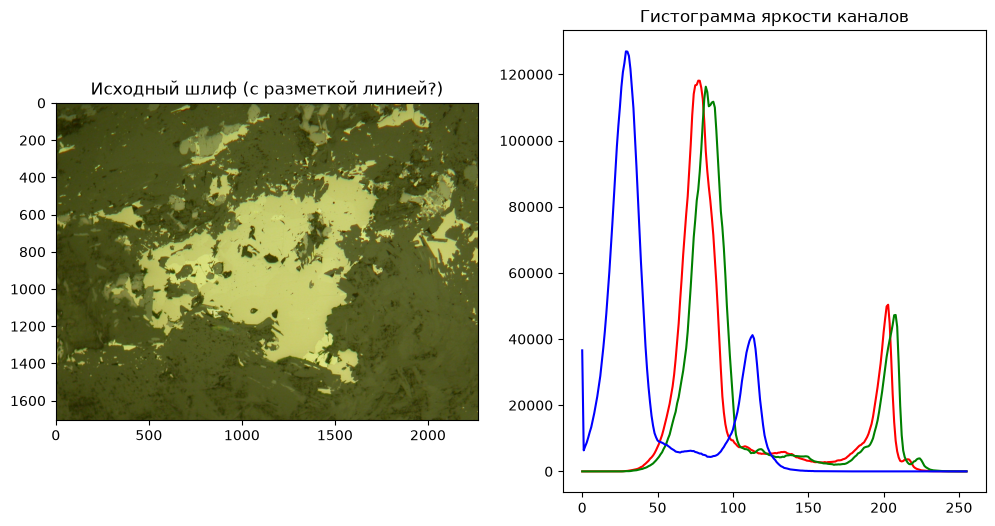

In [23]:
def load_and_inspect_image(path):
    # Безопасное чтение файлов с кириллицей в путях для Windows
    # Читаем файл как сырой поток байт, а затем декодируем через OpenCV
    file_bytes = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    
    if img is None:
        raise FileNotFoundError(f"Не удалось прочитать файл (возможно, поврежден): {path}")
        
    # Переводим из BGR в RGB для корректного отображения в matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb

# Возьмем для примера картинку из оталькованных руд (где есть разметка)
talc_samples = df_all[df_all['ore_class'] == 'оталькованная']['path'].values
if len(talc_samples) > 0:
    sample_img = load_and_inspect_image(talc_samples[0])
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Исходный шлиф (с разметкой линией?)")
    plt.imshow(sample_img)
    
    # Идея для выделения цветной линии (например, если она ярко-красная):
    # Порог в RGB: R > 200, G < 50, B < 50
    plt.subplot(1, 2, 2)
    plt.title("Гистограмма яркости каналов")
    for i, col in enumerate(['r', 'g', 'b']):
        hist = cv2.calcHist([sample_img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
    plt.show()
else:
    print("Нет изображений в классе 'оталькованная' для теста")

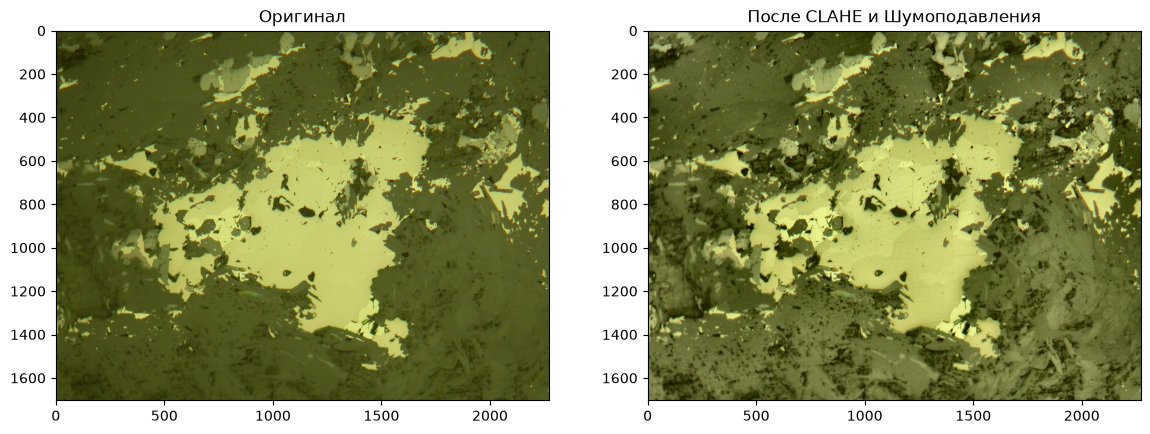

In [24]:
def preprocess_image(img_rgb):
    # 1. Переводим в LAB для выравнивания освещения без искажения цветов
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    
    # Применяем CLAHE (Adaptive Histogram Equalization) к каналу яркости L
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    
    # Собираем обратно
    limg = cv2.merge((cl,a,b))
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    
    # 2. Шумоподавление (размытие Гаусса или медианный фильтр)
    denoised = cv2.GaussianBlur(enhanced_img, (3, 3), 0)
    
    return denoised

# Проверяем работу предобработки
if len(talc_samples) > 0:
    original = load_and_inspect_image(talc_samples[0])
    processed = preprocess_image(original)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(original)
    axes[0].set_title("Оригинал")
    axes[1].imshow(processed)
    axes[1].set_title("После CLAHE и Шумоподавления")
    plt.show()

In [25]:
def make_tiles(image, tile_size=512, overlap=64):
    """
    Нарезает большое изображение на патчи (тайлы) для подачи в модель.
    """
    h, w, _ = image.shape
    stride = tile_size - overlap
    tiles = []
    coords = [] # Сохраняем координаты, чтобы потом собрать панораму обратно
    
    for y in range(0, h - tile_size + 1, stride):
        for x in range(0, w - tile_size + 1, stride):
            tile = image[y:y+tile_size, x:x+tile_size]
            tiles.append(tile)
            coords.append((x, y))
            
    return np.array(tiles), coords

print("Пайплайн готов к интеграции со скармливанием патчей в PyTorch/Segmentation-Models!")

Пайплайн готов к интеграции со скармливанием патчей в PyTorch/Segmentation-Models!
